In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator
import pandas as pd

files = {
    'Native': '/home/mengelsl/MA-bench-framework/outputs/krylov/_new/native/summary_final.csv',
    'SME': '/home/mengelsl/MA-bench-framework/outputs/krylov/_new/sme/summary_final.csv', 
    'SEV': '/home/mengelsl/MA-bench-framework/outputs/krylov/_new/sev/summary_final.csv'
}

dfs = []

for mode, path in files.items():
    temp_df = pd.read_csv(path)
    temp_df.insert(0, 'Mode', mode)
    dfs.append(temp_df)

df_raw = pd.concat(dfs, ignore_index=True)
df_raw['total_time'] = df_raw['Intern_SpMVTime'] + df_raw['Intern_MgmtTime']

def get_median_time_run(group):
    return group.loc[(group['total_time']- group['total_time'].median()).abs().idxmin()]

group_cols = ['Mode', 'Algo', 'Matrix', 'Cores', 'Arg1', 'Arg2', 'Arg3']
df_med = df_raw.groupby(group_cols, group_keys=False).apply(get_median_time_run, include_groups=False).reset_index()

df_med['ns_per_op'] = ((df_med['total_time']) * 1e9) / df_med['Intern_N_Ops']
df_med['spmv_mgmt_ratio'] = df_med['Intern_MgmtTime'] / df_med['total_time']
df_med.drop(columns=['Run'], inplace=True)
df = df_med.copy()

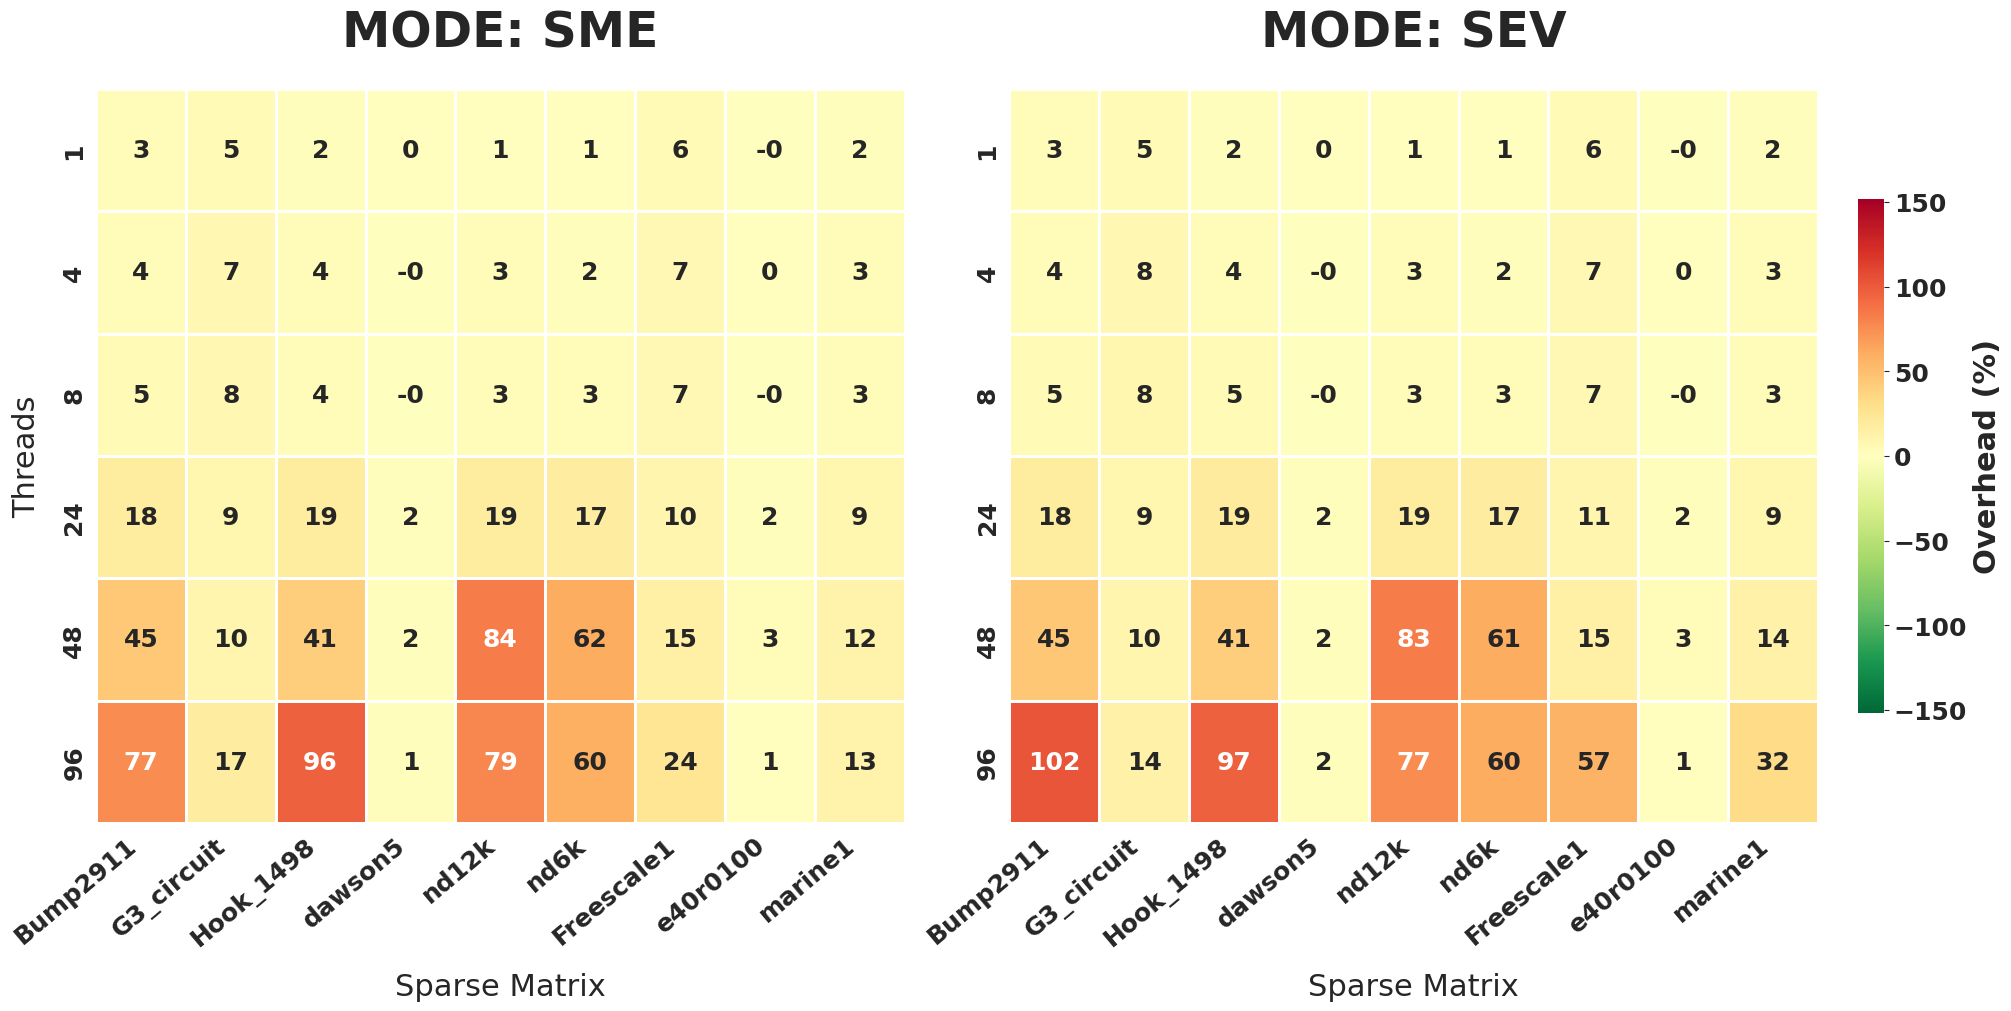

In [ ]:
pivot_cols = ['Algo', 'Matrix', 'Cores', 'Arg1', 'Arg2', 'Arg3']
df_pivot = df.pivot_table(index=pivot_cols, columns='Mode', values='ns_per_op').reset_index()
df_pivot['Diff_SME'] = (df_pivot['SME'] / df_pivot['Native'] - 1) * 100
df_pivot['Diff_SEV'] = (df_pivot['SEV'] / df_pivot['Native'] - 1) * 100

abs_max = max(abs(df_pivot[['Diff_SME', 'Diff_SEV']].min().min()), 
              abs(df_pivot[['Diff_SME', 'Diff_SEV']].max().max()))
v_min, v_max = -abs_max, abs_max

plt.rcParams.update({'font.family': 'sans-serif', 'font.weight': 'bold'})
fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

modes = ['SME', 'SEV']
for i, mode in enumerate(modes):
    col_name = f'Diff_{mode}'
    hm_data = df_pivot.pivot_table(index='Cores', columns='Matrix', values=col_name, aggfunc='mean')
    hm_data.columns = [c.split('/')[-1].replace('.bin', '') for c in hm_data.columns] # Kürzer ohne .bin
    
    sns.heatmap(
        hm_data, 
        annot=True, 
        fmt=".0f", 
        cmap="RdYlGn_r", 
        center=0,
        vmin=v_min, vmax=v_max,
        ax=axes[i],
        cbar=(i == 1), 
        cbar_kws={'label': 'Overhead (%)', 'shrink': 0.7} if i == 1 else None,
        annot_kws={"weight": "extra bold", "size": 18}, # MASSIVE Zahlen in den Zellen
        linewidths=1,
        linecolor='white'
    )
    
    axes[i].set_title(f'MODE: {mode}', fontsize=35, fontweight='black', pad=30)
    axes[i].set_xlabel('Sparse Matrix', fontsize=22, labelpad=15)
    axes[i].set_ylabel('Threads' if i == 0 else '', fontsize=22, labelpad=15)
    
    axes[i].tick_params(axis='both', which='major', labelsize=18)
    plt.setp(axes[i].get_xticklabels(), rotation=40, ha='right')

if len(fig.axes) > 2:
    fig.axes[-1].tick_params(labelsize=18)
    fig.axes[-1].set_ylabel('Overhead (%)', fontsize=22, fontweight='bold')

plt.show()

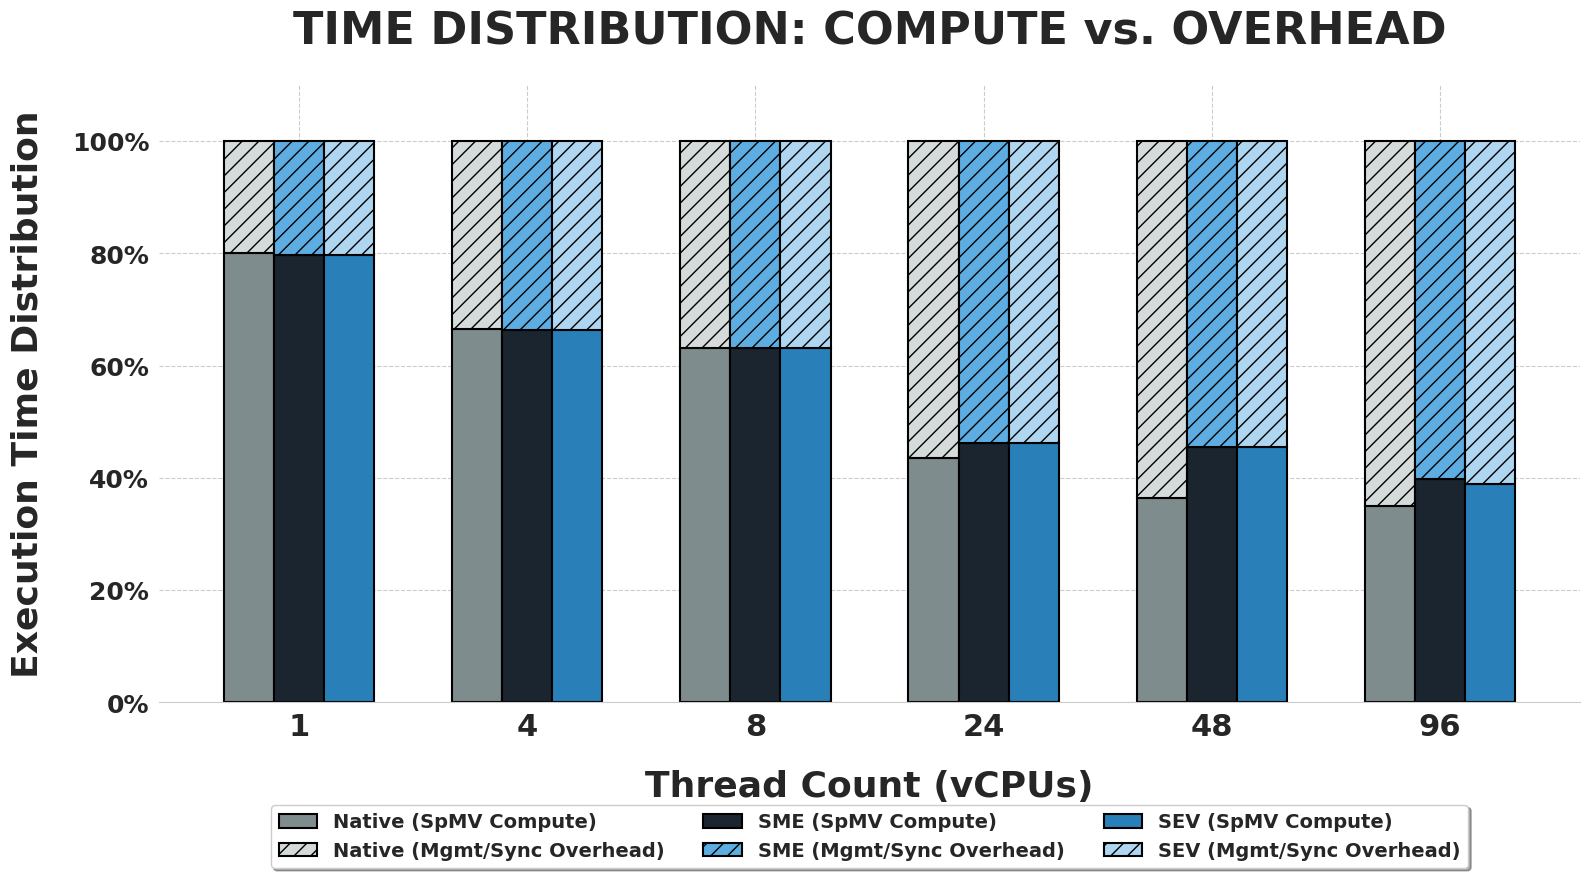

In [ ]:
plot_data = df.groupby(['Mode', 'Cores'])['spmv_mgmt_ratio'].mean().reset_index()
plot_data['spmv_ratio'] = 1 - plot_data['spmv_mgmt_ratio']

mode_order = ['Native', 'SME', 'SEV']
available_modes = [m for m in mode_order if m in plot_data['Mode'].unique()]

colors_spmv = {'Native': '#7f8c8d', 'SME': '#1a252f', 'SEV': '#2980b9'}
colors_mgmt = {'Native': '#d5dbdb', 'SME': '#5dade2', 'SEV': '#aed6f1'}

plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
fig, ax = plt.subplots(figsize=(16, 9))
sns.set_style("whitegrid", {'grid.linestyle': ':', 'grid.alpha': 0.7})

cores = sorted(plot_data['Cores'].unique())
x = np.arange(len(cores))
width = 0.22 

for i, mode in enumerate(available_modes):
    subset = plot_data[plot_data['Mode'] == mode].set_index('Cores').reindex(cores).fillna(0)
    pos = x + (i * width) - ((len(available_modes) - 1) * width / 2)
    
    ax.bar(pos, subset['spmv_ratio'], width, 
           label=f'{mode} (SpMV Compute)', 
           color=colors_spmv[mode], edgecolor='black', linewidth=1.5)
    
    ax.bar(pos, subset['spmv_mgmt_ratio'], width, 
           bottom=subset['spmv_ratio'], 
           label=f'{mode} (Mgmt/Sync Overhead)', 
           color=colors_mgmt[mode], hatch='//', 
           edgecolor='black', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(cores, fontsize=22)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=18)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Execution Time Distribution', fontsize=26, labelpad=20)
ax.set_xlabel('Thread Count (vCPUs)', fontsize=26, labelpad=20)
ax.set_title('TIME DISTRIBUTION: COMPUTE vs. OVERHEAD', fontsize=32, fontweight='black', pad=30)

ax.legend(fontsize=14, ncol=len(available_modes), loc='upper center', 
          bbox_to_anchor=(0.5, -0.15), frameon=True, shadow=True)

sns.despine(left=True)
plt.tight_layout()
plt.show()